Training XGBoost...


d:\Behvaior Analysis\banalysis\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:46:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Evaluating XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 115
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 18
[LightGBM] [Info] Start training from score -2.490170
[LightGBM] [Info] Start training from score -2.486783
[LightGBM] [Info] Start training from score -2.482036
[LightGBM] [Info] Start training from score -2.494831
[LightGBM] [Info] Start training from score -2.480417
[LightGBM] [Info] Start training from score -2.495841
[LightGBM] [Info] Start training from score -2.490170
[LightGBM] [Info] Start training from score -2.472237
[LightGBM] [Info] Start training from score -2.477062
[LightGBM] [Info] Start training from s

d:\Behvaior Analysis\banalysis\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Evaluating TabNet...

Classification Report Comparison:

XGBoost:

              precision    recall  f1-score       support
0              0.927014  0.923513  0.925260   1059.000000
1              0.899010  0.920892  0.909820    986.000000
2              0.901575  0.943357  0.921993    971.000000
3              0.908917  0.912416  0.910663   1039.000000
4              0.904222  0.885081  0.894549    992.000000
5              0.919508  0.899074  0.909176   1080.000000
6              0.932914  0.882937  0.907238   1008.000000
7              0.876258  0.924628  0.899793    942.000000
8              0.925966  0.902720  0.914195    956.000000
9              0.909621  0.930417  0.919902   1006.000000
10             0.922686  0.899802  0.911100   1008.000000
11             0.887147  0.890871  0.889005    953.000000
accuracy       0.909583  0.909583  0.909583      0.909583
macro avg      0.909570  0.909642  0.909391  12000.000000
weighted avg   0.909968  0.909583  0.909564  12000.000000

Ligh

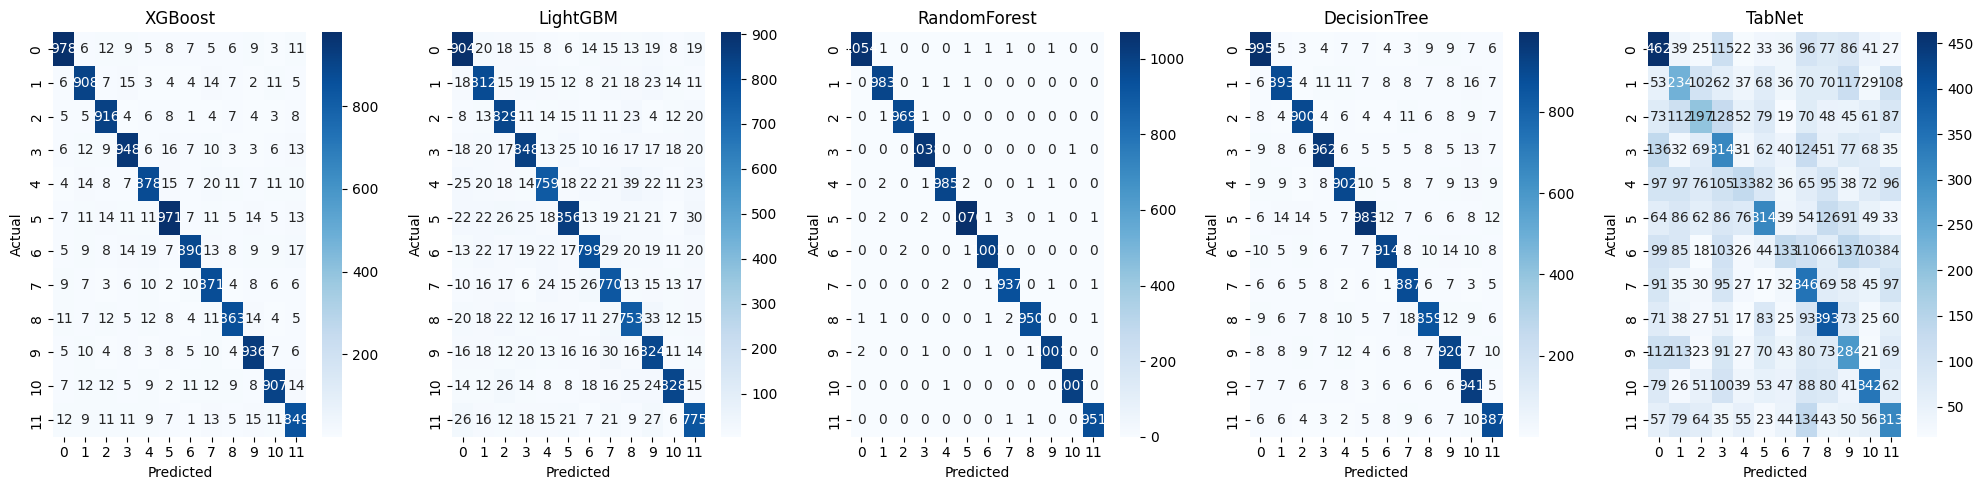

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier  # Importing DecisionTreeClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
data = pd.read_csv('resampled_data.csv')

# Preprocessing
# Separate features and labels
X = data.drop(columns=['Suggested Job Role'])  # Drop non-numeric or target columns
y = data['Suggested Job Role']  # Target variable

# If 'Suggested Job Role' is categorical, encode it
y = LabelEncoder().fit_transform(y)

# Scale numeric features
scaler = StandardScaler()
X[X.select_dtypes(include=[np.number]).columns] = scaler.fit_transform(
    X.select_dtypes(include=[np.number]).values
)

# Train-test-validation split (80-10-10 split)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Initialize models (added Decision Tree)
models = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(),
    'RandomForest': RandomForestClassifier(),
    'DecisionTree': DecisionTreeClassifier(),  # Added Decision Tree
    'TabNet': TabNetClassifier(verbose=0)
}

results = {}
confusion_matrices = {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == 'TabNet':  # TabNet requires NumPy arrays
        model.fit(
            X_train.to_numpy(), y_train,
            eval_set=[(X_val.to_numpy(), y_val)],
            eval_name=['val'],
            eval_metric=['accuracy'],
            patience=10,
        )
    else:
        model.fit(X_train, y_train)
    
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test.to_numpy() if name == 'TabNet' else X_test)
    
    # Save results
    results[name] = classification_report(y_test, y_pred, output_dict=True)
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

# Compare Models
print("\nClassification Report Comparison:")
for name, report in results.items():
    print(f"\n{name}:\n")
    print(pd.DataFrame(report).transpose())

# Plot Confusion Matrices
fig, axes = plt.subplots(1, len(models), figsize=(20, 5))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


Training XGBoost...


d:\Behvaior Analysis\banalysis\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:27:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Evaluating XGBoost...

XGBoost Classification Report:

              precision    recall  f1-score       support
0              0.927014  0.923513  0.925260   1059.000000
1              0.899010  0.920892  0.909820    986.000000
2              0.901575  0.943357  0.921993    971.000000
3              0.908917  0.912416  0.910663   1039.000000
4              0.904222  0.885081  0.894549    992.000000
5              0.919508  0.899074  0.909176   1080.000000
6              0.932914  0.882937  0.907238   1008.000000
7              0.876258  0.924628  0.899793    942.000000
8              0.925966  0.902720  0.914195    956.000000
9              0.909621  0.930417  0.919902   1006.000000
10             0.922686  0.899802  0.911100   1008.000000
11             0.887147  0.890871  0.889005    953.000000
accuracy       0.909583  0.909583  0.909583      0.909583
macro avg      0.909570  0.909642  0.909391  12000.000000
weighted avg   0.909968  0.909583  0.909564  12000.000000


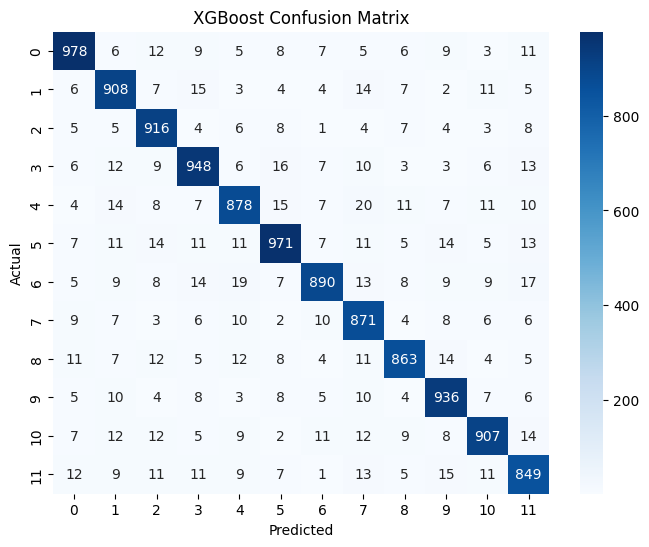

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
data = pd.read_csv('resampled_data.csv')

# Preprocessing
# Separate features and labels
X = data.drop(columns=['Suggested Job Role'])  # Adjust for actual target column names
y = data['Suggested Job Role']

# Scale numeric features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Encode target column
y = y.astype('category').cat.codes  # Convert target to categorical codes if necessary

# Train-test-validation split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Initialize XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Training
print("Training XGBoost...")
model.fit(X_train, y_train)

# Evaluating
print("Evaluating XGBoost...")
y_pred = model.predict(X_test)

# Save results
classification_rep = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display Classification Report
print("\nXGBoost Classification Report:\n")
print(pd.DataFrame(classification_rep).transpose())

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


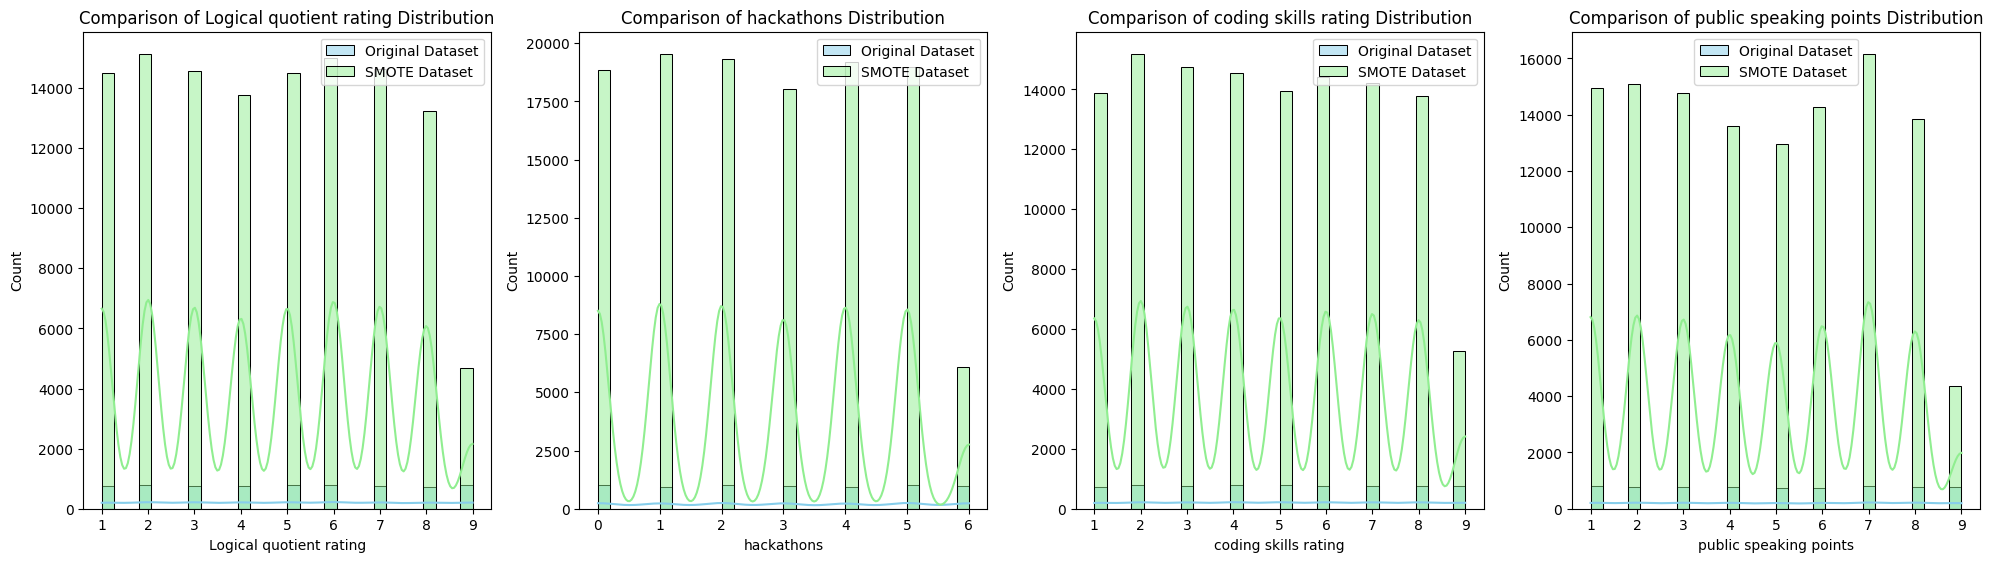

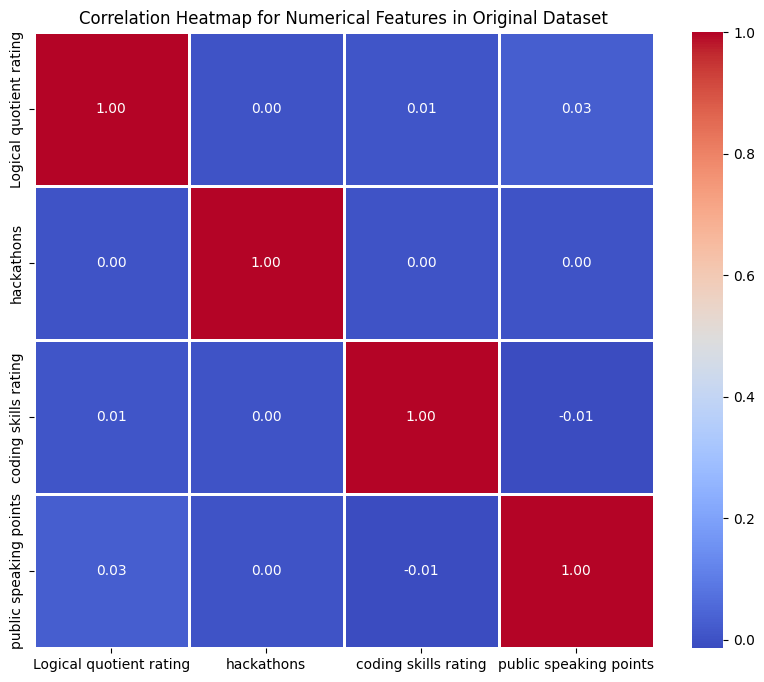

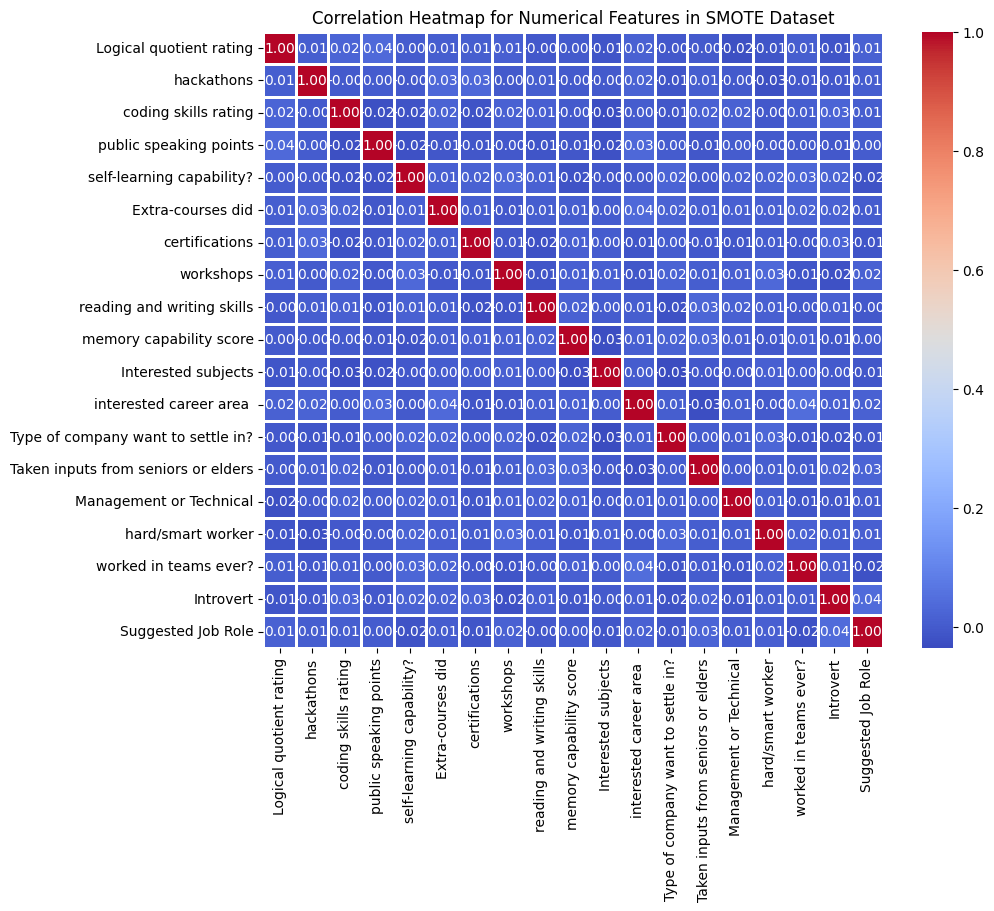

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
mldata = pd.read_csv('mldata.csv')  # Original dataset with mixed text and numerical data
resampled_data = pd.read_csv('resampled_data.csv')  # After SMOTE, only numerical data

# --- Data Distribution Comparison ---
numerical_cols = mldata.select_dtypes(include=[np.number]).columns

# Combine feature distribution for both datasets for comparison
plt.figure(figsize=(20, 16))
for col in numerical_cols:
    plt.subplot(3, 4, numerical_cols.get_loc(col) + 1)  # Adjusted subplot index for layout
    sns.histplot(mldata[col], kde=True, color='skyblue', label='Original Dataset', bins=30)
    sns.histplot(resampled_data[col], kde=True, color='lightgreen', label='SMOTE Dataset', alpha=0.5, bins=30)
    plt.title(f'Comparison of {col} Distribution')
    plt.legend()
plt.tight_layout()
plt.show()

# --- Correlation Heatmap Comparison ---
# Correlation heatmap for numerical features in mldata.csv
plt.figure(figsize=(10, 8))
sns.heatmap(mldata[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap for Numerical Features in Original Dataset')
plt.show()

# Correlation heatmap for numerical features in resampled_data.csv
plt.figure(figsize=(10, 8))
sns.heatmap(resampled_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap for Numerical Features in SMOTE Dataset')
plt.show()


In [2]:
import pandas as pd

# Replace 'your_file.csv' with the path to your CSV file
csv_file = 'mldata.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(csv_file)

# Replace 'label' with the name of the column containing labels
label_column = 'Suggested Job Role'

# Get unique label values
unique_labels = df[label_column].unique()

# Print the unique label values
print("Unique label values:")
for label in unique_labels:
    print(label)


Unique label values:
Applications Developer
CRM Technical Developer
Database Developer
Mobile Applications Developer
Network Security Engineer
Software Developer
Software Engineer
Software Quality Assurance (QA) / Testing
Systems Security Administrator
Technical Support
UX Designer
Web Developer
